### Introduction


#### Demographic Information
*   **`Gender`**: Gender of the individual 
*   **`Age`**: Age of the individual in years 
*   **`Height`**: Height of the individual in meters 
*   **`Weight`**: Weight of the individual in kilograms 

#### Eating Habits
*   **`family_history_with_overweight`**: Has a family member suffered or suffers from overweight? 
*   **`FAVC`**: Do you eat high caloric food frequently? 
*   **`FCVC`**: Do you usually eat vegetables in your meals? 
*   **`NCP`**: How many main meals do you have daily? 
*   **`CAEC`**: Do you eat any food between meals? 
*   **`CH2O`**: How much water do you drink daily? 
*   **`CALC`**: How often do you drink alcohol? 

#### Physical Condition & Lifestyle
*   **`SMOKE`**: Do you smoke? 
*   **`SCC`**: Do you monitor the calories you eat daily? 
*   **`FAF`**: How often do you have physical activity? 
*   **`TUE`**: How much time do you use technological devices daily? 
*   **`MTRANS`**: What transportation do you usually use? 
---
#### Target Variable
*   **`NObeyesdad`** (or **`NObesity`**): 
    *   `Insufficient Weight`
    *   `Normal Weight`
    *   `Overweight Level I`
    *   `Overweight Level II`
    *   `Obesity Type I`
    *   `Obesity Type II`
    *   `Obesity Type III`

### Imports ###

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import time
from flaml import AutoML
import torch
import torch.nn as nn
from timeit import default_timer as timer 
import pickle





## Initial Look at the Dataset

### Load Dataset

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### EDA

In [3]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


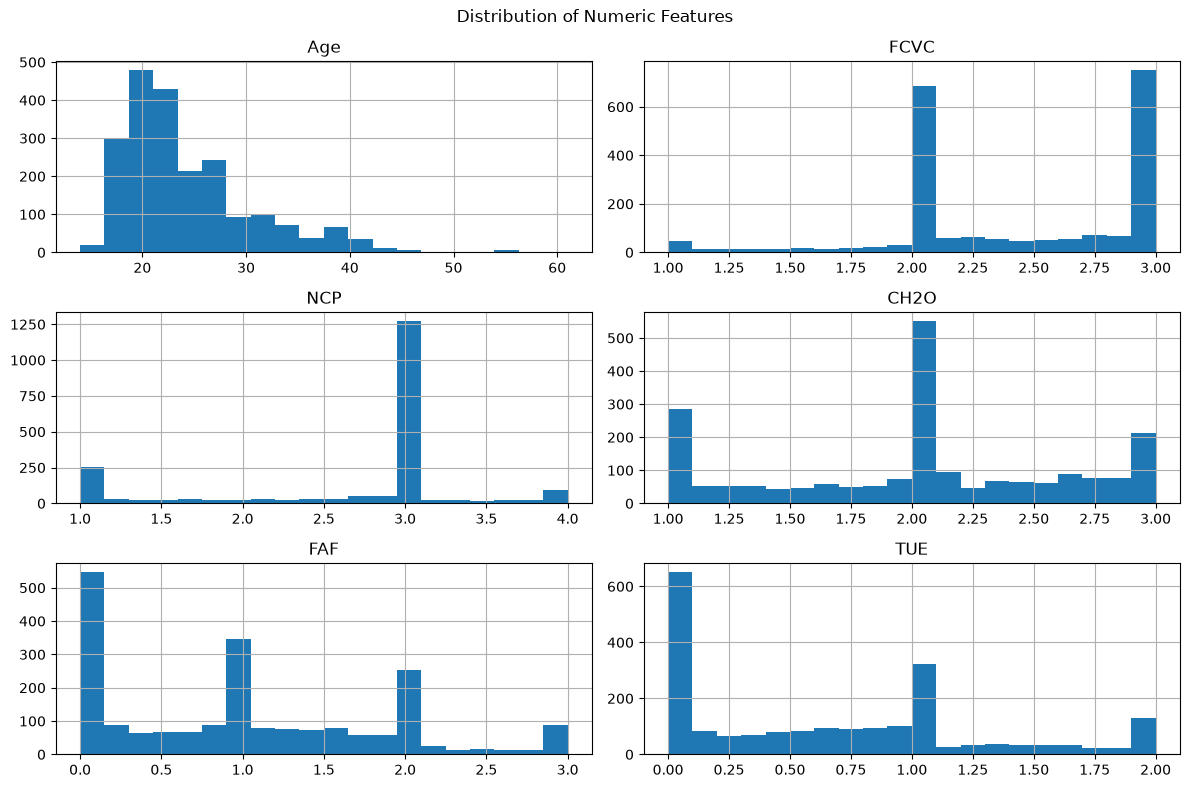

In [4]:
num_features = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[num_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

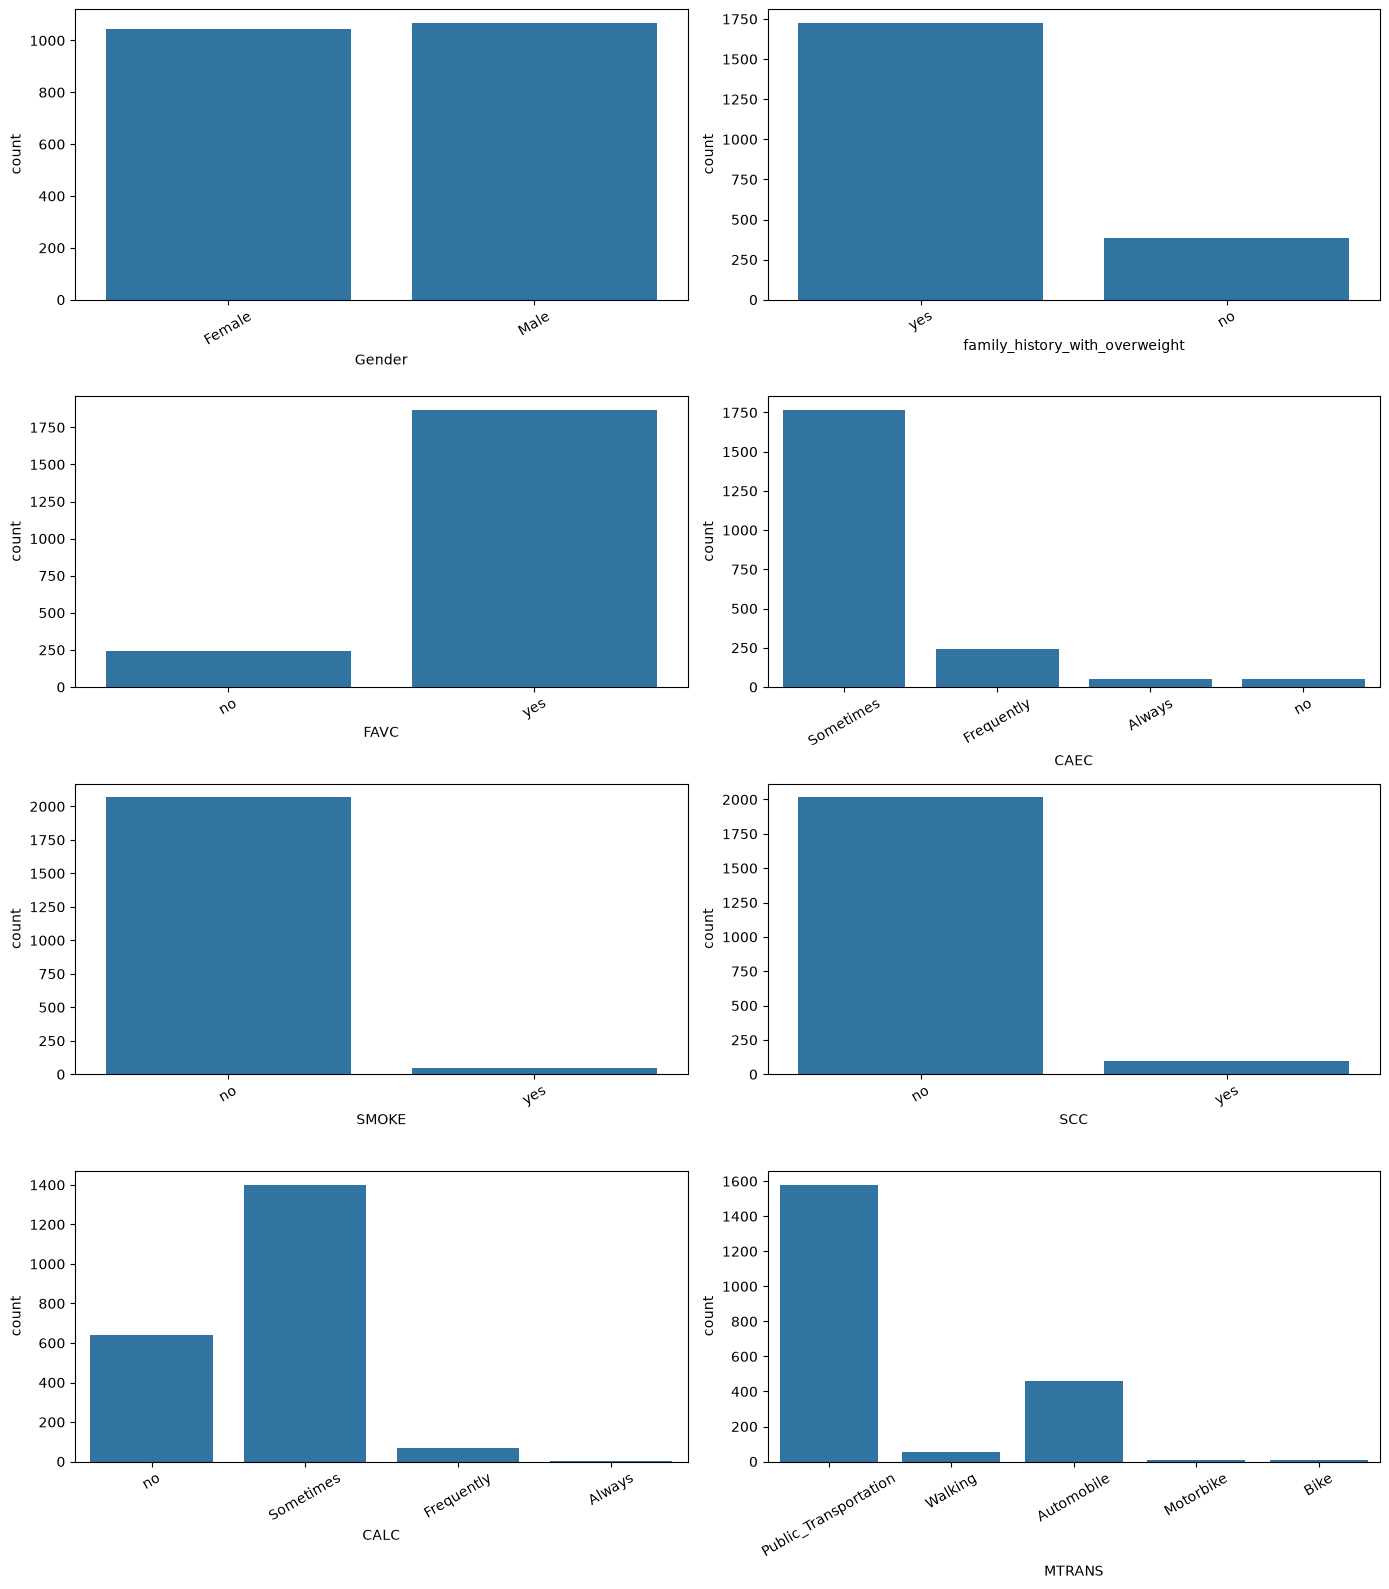

In [5]:
cat_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), cat_features):
    sns.countplot(data=df, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [6]:
df.shape

(2111, 17)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [8]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

### Feature Engineering

In [9]:
# Convert kg to lbs
df['Weight_lbs'] = df['Weight'] * 2.20462   

In [10]:
# Convert meters to inches
df['Height_in'] = df['Height'] * 39.3701

In [11]:
# Calculate BMI and round to 1 decimal place
df['BMI'] = (df['Weight_lbs'] / (df['Height_in'] ** 2)) * 703
df['BMI'] = df['BMI'].round(1)

In [12]:
# Drop the height and weight columns
df = df.drop(columns=['Height', 'Weight'])

In [13]:
df.rename(columns={'NObeyesdad': 'Obesity_Class'}, inplace=True)

### Visualize Data

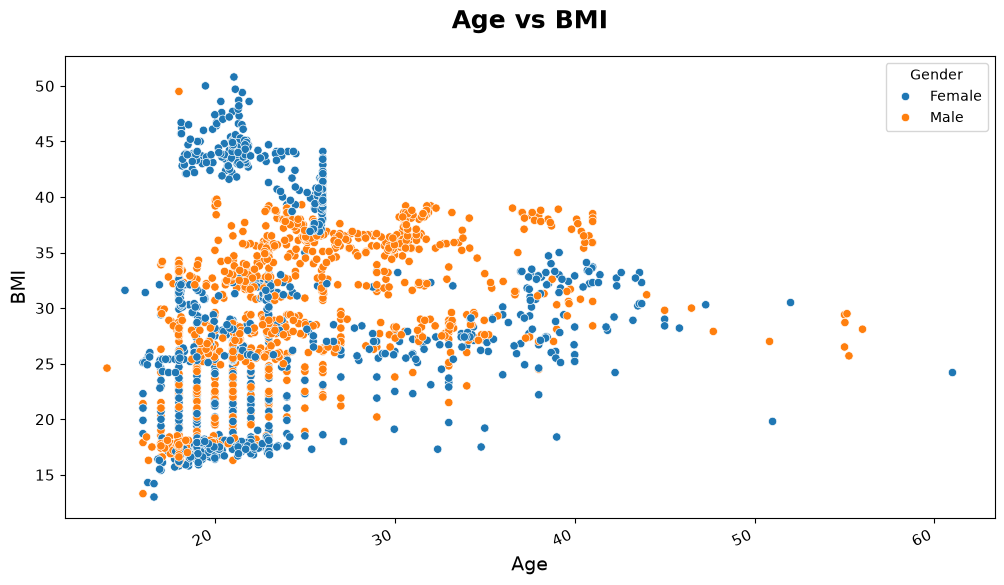

In [14]:
plt.figure(figsize=(12, 6))
# Title and labels
plt.title("Age vs BMI", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Age", fontsize=14)
plt.ylabel("BMI", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)
sns.scatterplot(data=df, x="Age", y="BMI", hue="Gender")
plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

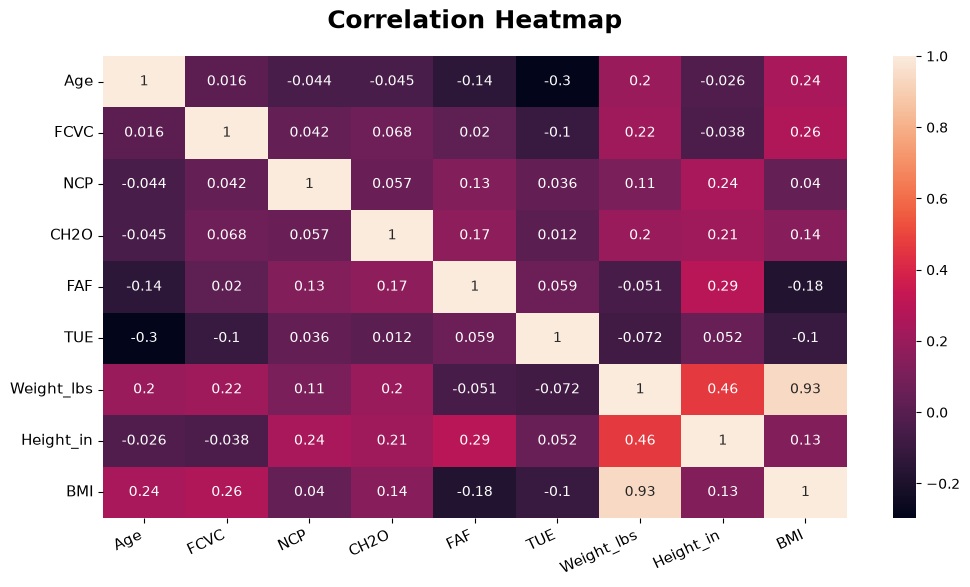

In [15]:
plt.figure(figsize=(12, 6))

# Title and labels
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold", pad=20)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Create figure

sns.heatmap(df.corr(numeric_only=True), annot=True)

/tmp/ipykernel_2719/1803359615.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


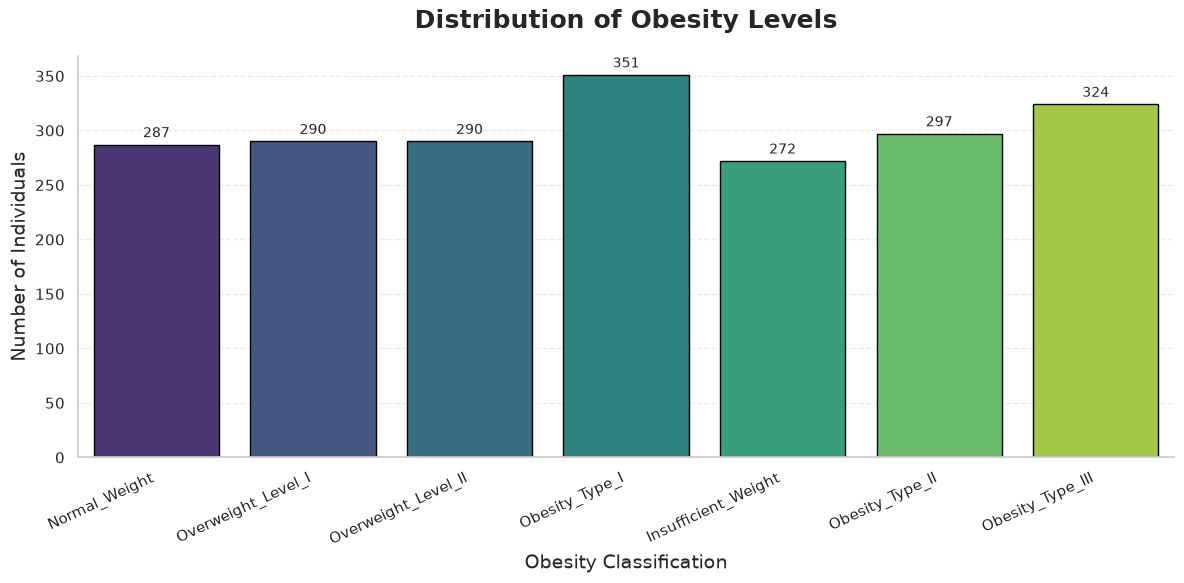

In [16]:
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Create count plot
ax = sns.countplot(
    data=df,
    x="Obesity_Class",
    palette="viridis",
    legend=False,
    edgecolor="black"
)

# Title and labels
plt.title("Distribution of Obesity Levels", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Obesity Classification", fontsize=14)
plt.ylabel("Number of Individuals", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=10, padding=3)

# Improve appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:
df.columns

Index(['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity_Class', 'Weight_lbs', 'Height_in', 'BMI'],
      dtype='str')

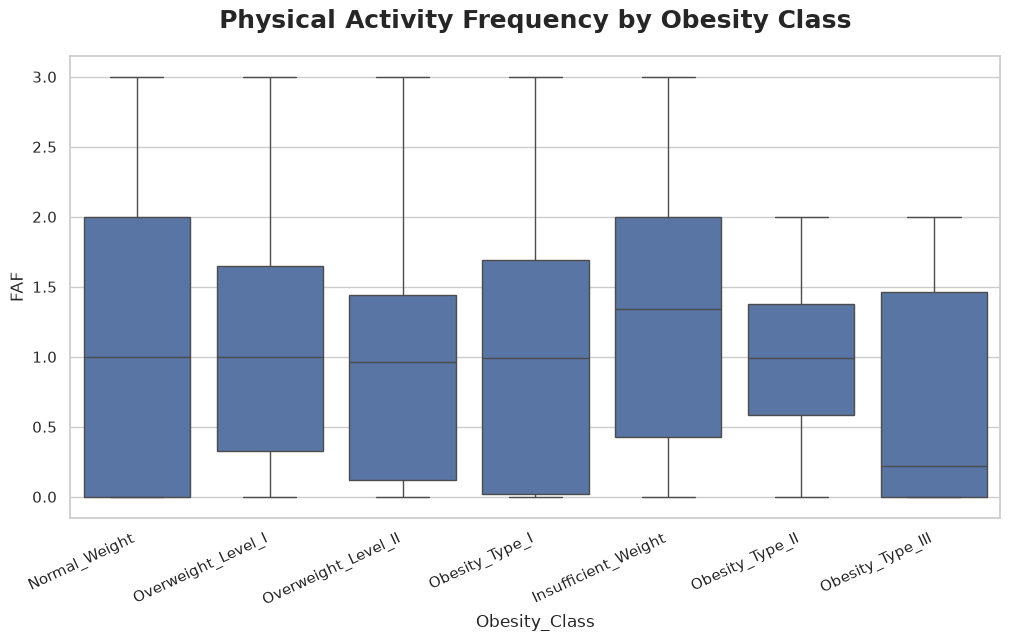

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Obesity_Class', y='FAF')
plt.xticks(rotation=25, ha='right')
plt.title("Physical Activity Frequency by Obesity Class", fontsize=18, fontweight="bold", pad=20)
plt.show()

In [19]:
df = df.drop(columns=['Weight_lbs', 'Height_in', 'BMI'])

<Axes: title={'center': 'Correlation Heatmap (post leakage from Height, Weight, and BMI)'}>

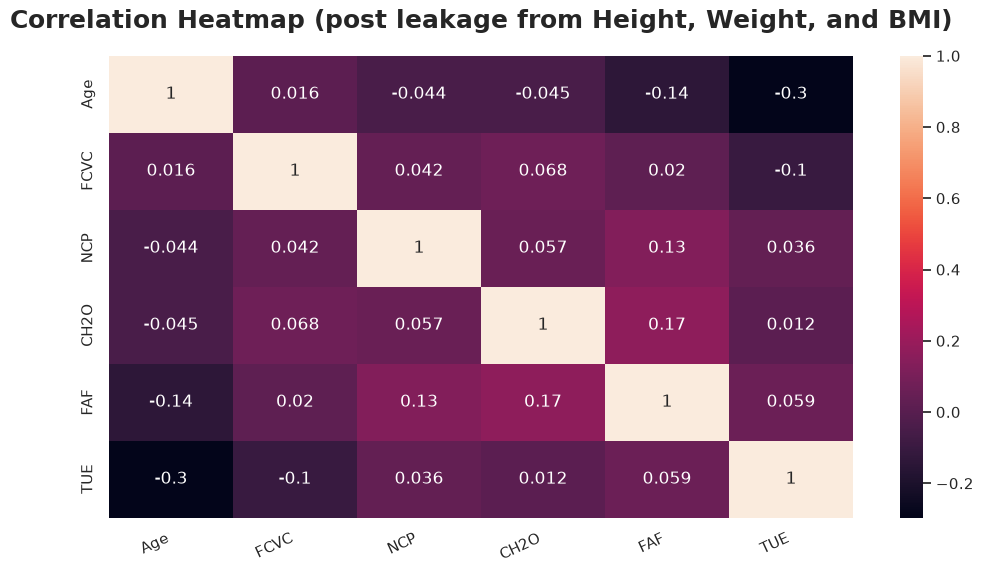

In [20]:
plt.figure(figsize=(12, 6))

# Title and labels
plt.title("Correlation Heatmap (post leakage from Height, Weight, and BMI)", fontsize=18, fontweight="bold", pad=20)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Create figure

sns.heatmap(df.corr(numeric_only=True), annot=True)

### Train/Test Split

In [21]:
X = df.drop(columns=['Obesity_Class'])
y = df['Obesity_Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
preprocessor = make_column_transformer(
      (StandardScaler(),
       make_column_selector(dtype_include=np.number)),  
      (OneHotEncoder(),
       make_column_selector(dtype_include=[object, "string"]))) 

## Models

### Decision Tree


##### Default Settings

In [23]:
decision_tree_pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', DecisionTreeClassifier(random_state=42))])

start_train = time.perf_counter()
decision_tree_pipe.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train

In [24]:
start_query = time.perf_counter()
y_test_pred = decision_tree_pipe.predict(X_test)
end_query = time.perf_counter()

query_time = end_query - start_query

y_train_pred = decision_tree_pipe.predict(X_train)

In [25]:
print("Default Training Accuracy:", accuracy_score(y_train, y_train_pred))
print(f"Training Time: {train_time:.4f} seconds")
print("Default Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print(f"Query Time:    {query_time:.4f} seconds")

Default Training Accuracy: 1.0
Training Time: 0.1107 seconds
Default Testing Accuracy: 0.7399527186761229
Query Time:    0.0132 seconds


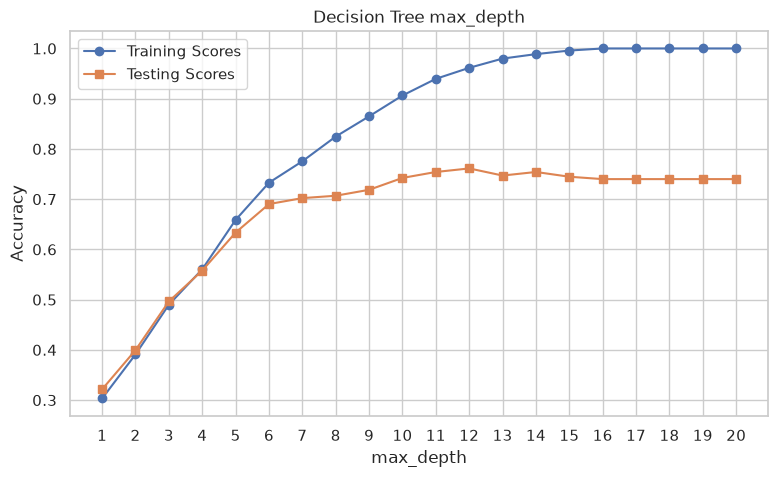

In [26]:
train_scores = []
test_scores = []
depths = range(1, 21)
for d in depths:
    d_tree = Pipeline([('preprocessor', preprocessor),
                 ('model', DecisionTreeClassifier(random_state=42, max_depth=d))])
    d_tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, d_tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, d_tree.predict(X_test)))



plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label="Training Scores", marker="o")
plt.plot(depths, test_scores, label="Testing Scores", marker="s")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.legend()
plt.title("Decision Tree max_depth")
plt.show()

##### Best max_depth

In [27]:
decision_tree_pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', DecisionTreeClassifier(random_state=42, max_depth=10))])

start_train = time.perf_counter()
decision_tree_pipe.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train

In [28]:
start_query = time.perf_counter()
y_test_pred = decision_tree_pipe.predict(X_test)
end_query = time.perf_counter()

query_time = end_query - start_query

y_train_pred = decision_tree_pipe.predict(X_train)

In [29]:
dt_test_acc = accuracy_score(y_test, y_test_pred)
dt_train_acc = accuracy_score(y_train, y_train_pred)
dt_train_time = train_time
dt_query_time = query_time

print("Optomized Training Accuracy:", dt_test_acc)
print(f"Training Time: {dt_train_time:.4f} seconds")
print("Optomized Testing Accuracy:", dt_train_acc)
print(f"Query Time:    {dt_query_time:.4f} seconds")

Optomized Training Accuracy: 0.7423167848699763
Training Time: 0.0389 seconds
Optomized Testing Accuracy: 0.9063981042654028
Query Time:    0.0109 seconds


### Logistic Regression

In [30]:
logistic_regression_pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', LogisticRegression(random_state=42, max_iter=500))])

start_train = time.perf_counter()
logistic_regression_pipe.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train

In [31]:
start_query = time.perf_counter()
y_test_pred = logistic_regression_pipe.predict(X_test)
end_query = time.perf_counter()

query_time = end_query - start_query

y_train_pred = logistic_regression_pipe.predict(X_train)

In [32]:
lr_test_acc = accuracy_score(y_test, y_test_pred)
lr_train_acc = accuracy_score(y_train, y_train_pred)
lr_train_time = train_time
lr_query_time = query_time

print("Training Accuracy:", lr_train_acc)
print(f"Training Time: {lr_train_time:.4f} seconds")
print("Testing Accuracy:", lr_test_acc)
print(f"Query Time:    {lr_query_time:.4f} seconds")

Training Accuracy: 0.634478672985782
Training Time: 0.4464 seconds
Testing Accuracy: 0.624113475177305
Query Time:    0.0135 seconds


### AutoML

In [33]:
automl = AutoML()

automl_settings = {
    "time_budget": 30, 
    "metric": "accuracy",
    "task": "classification",
    "seed": 42,
}

# Train with labeled input data
start_train = time.perf_counter()
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

end_train = time.perf_counter()
automl_train_time = end_train - start_train

# Predict
start_query = time.perf_counter()
automl_y_pred = automl.predict(X_test)
end_query = time.perf_counter()

automl_query_time = end_query - start_query

# Compute accuracies
automl_train_acc = accuracy_score(y_train, automl.predict(X_train))
automl_test_acc = accuracy_score(y_test, automl_y_pred)

[flaml.automl.logger: 07-27 01:50:57] {2375} INFO - task = classification
[flaml.automl.logger: 07-27 01:50:57] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 07-27 01:50:57] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 07-27 01:50:57] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 07-27 01:50:57] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-27 01:50:58] {3046} INFO - Estimated sufficient time budget=4969s. Estimated necessary time budget=115s.
[flaml.automl.logger: 07-27 01:50:58] {3097} INFO -  at 0.5s,	estimator lgbm's best error=4.0340e-01,	best estimator lgbm's best error=4.0340e-01
[flaml.automl.logger: 07-27 01:50:58] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-27 01:50:58] {3097} INFO -  at 0.7s,	estimator lgbm's best error=4.0340e-01,	best estimator lgbm's best error=4.0340e-01
[flaml.aut

[flaml.automl.logger: 07-27 01:50:58] {3097} INFO -  at 1.1s,	estimator lgbm's best error=2.8553e-01,	best estimator lgbm's best error=2.8553e-01
[flaml.automl.logger: 07-27 01:50:58] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 07-27 01:50:59] {3097} INFO -  at 1.3s,	estimator lgbm's best error=2.8553e-01,	best estimator lgbm's best error=2.8553e-01
[flaml.automl.logger: 07-27 01:50:59] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 07-27 01:50:59] {3097} INFO -  at 1.7s,	estimator lgbm's best error=2.8019e-01,	best estimator lgbm's best error=2.8019e-01
[flaml.automl.logger: 07-27 01:50:59] {2911} INFO - iteration 6, current learner sgd
[flaml.automl.logger: 07-27 01:51:00] {3097} INFO -  at 2.3s,	estimator sgd's best error=8.3827e-01,	best estimator lgbm's best error=2.8019e-01
[flaml.automl.logger: 07-27 01:51:00] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 07-27 01:51:00] {3097} INFO -  at 2.7s,	estimator lg

In [34]:
print(f"--- AutoML Results ---")
print(f"Selected Best Learner:       {automl.best_estimator}")
print(f"Selected Hyperparameters:    {automl.best_config}")
print(f"Search Duration (Training): {automl_train_time:.4f} seconds")
print(f"Query Time (Inference):     {automl_query_time:.4f} seconds")
print(f"Training Accuracy:           {automl_train_acc:.4f}")
print(f"Testing Accuracy:            {automl_test_acc:.4f}")

--- AutoML Results ---
Selected Best Learner:       lgbm
Selected Hyperparameters:    {'n_estimators': 23, 'num_leaves': 27, 'min_child_samples': 12, 'learning_rate': np.float64(0.4814741778970618), 'log_max_bin': 4, 'colsample_bytree': np.float64(0.871435071208942), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(3.639093598824941)}
Search Duration (Training): 30.1518 seconds
Query Time (Inference):     0.0247 seconds
Training Accuracy:           0.9941
Testing Accuracy:            0.8227


### Random Forest

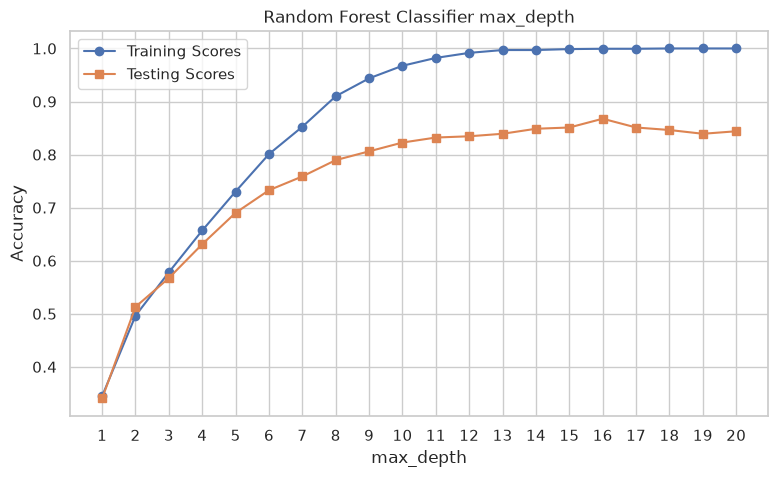

In [35]:
train_scores = []
test_scores = []
depths = range(1, 21)
for d in depths:
    d_tree = Pipeline([('preprocessor', preprocessor),
                 ('model', RandomForestClassifier(random_state=42, max_depth=d))])
    d_tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, d_tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, d_tree.predict(X_test)))



plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label="Training Scores", marker="o")
plt.plot(depths, test_scores, label="Testing Scores", marker="s")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.legend()
plt.title("Random Forest Classifier max_depth")
plt.show()

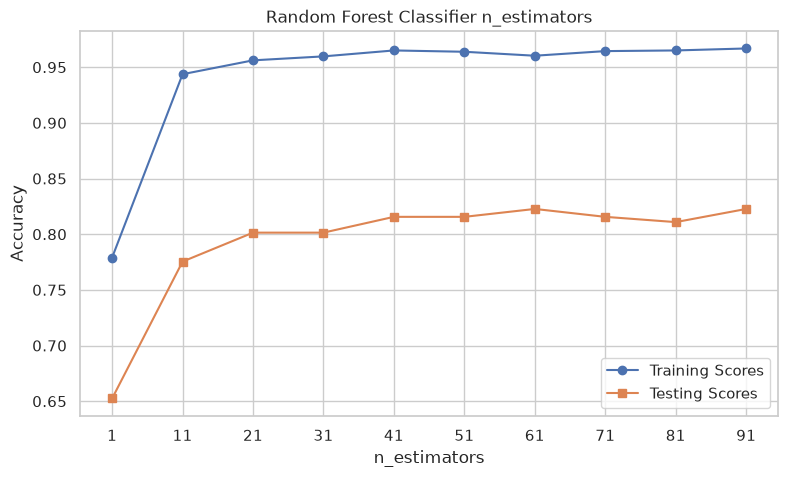

In [36]:
train_scores = []
test_scores = []
depths = range(1, 100, 10)
for d in depths:
    d_tree = Pipeline([('preprocessor', preprocessor),
                 ('model', RandomForestClassifier(random_state=42, n_estimators=d, max_depth=10))])
    d_tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, d_tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, d_tree.predict(X_test)))



plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label="Training Scores", marker="o")
plt.plot(depths, test_scores, label="Testing Scores", marker="s")

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.legend()
plt.title("Random Forest Classifier n_estimators")
plt.show()

In [37]:
random_forest_pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', RandomForestClassifier(random_state=42, n_estimators=20, max_depth=10))])

start_train = time.perf_counter()
random_forest_pipe.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train

In [38]:
start_query = time.perf_counter()
y_test_pred = random_forest_pipe.predict(X_test)
end_query = time.perf_counter()

query_time = end_query - start_query

y_train_pred = random_forest_pipe.predict(X_train)

In [39]:
rf_test_acc = accuracy_score(y_test, y_test_pred)
rf_train_acc = accuracy_score(y_train, y_train_pred)
rf_train_time = train_time
rf_query_time = query_time

print("Training Accuracy:", rf_train_acc)
print(f"Training Time: {rf_train_time:.4f} seconds")
print("Testing Accuracy:", rf_test_acc)
print(f"Query Time:    {rf_query_time:.4f} seconds")

Training Accuracy: 0.9549763033175356
Training Time: 0.0806 seconds
Testing Accuracy: 0.7943262411347518
Query Time:    0.0132 seconds


### Nueral Network

In [40]:
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_test_proc = X_test_proc.toarray()

# 2. Encode text labels into integers (0, 1, 2, ..., 6)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 3. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

In [41]:
torch.manual_seed(42)

class ObesityClassModel(nn.Module):
    def __init__(self, input_shape, output_shape):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_shape, out_features=64), 
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_shape)

        )

    def forward(self, x):
        return self.layer_stack(x)

In [42]:
torch.manual_seed(42)

model = ObesityClassModel(input_shape=X_train_tensor.shape[1], output_shape=len(torch.unique(y_train_tensor)))

In [43]:
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.1)

In [44]:
torch.manual_seed(42)

loss_history = []
start_train = time.perf_counter()

# Set the number of epochs
epochs = 100

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model.train()

    optimizer.zero_grad()

    y_logits = model(X_train_tensor) 
    loss = loss_fn(y_logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    
nn_train_time = time.perf_counter() - start_train

### Testing
model.eval()
with torch.inference_mode():
    start_query = time.perf_counter()
    train_logits = model(X_train_tensor)
    test_logits = model(X_test_tensor)

    train_preds = torch.argmax(train_logits, dim=1).cpu().numpy()
    test_preds = torch.argmax(test_logits, dim=1).cpu().numpy()

nn_query_time = time.perf_counter() - start_query

nn_train_acc = accuracy_score(y_train_enc, train_preds)
nn_test_acc = accuracy_score(y_test_enc, test_preds)

print(f"--- PyTorch Neural Network ---")
print(f"Training Time: {nn_train_time:.4f} s | Query Time: {nn_query_time:.4f} s")
print(f"Train Accuracy: {nn_train_acc:.4f} | Test Accuracy: {nn_test_acc:.4f}")

--- PyTorch Neural Network ---
Training Time: 0.9641 s | Query Time: 0.0043 s
Train Accuracy: 0.9662 | Test Accuracy: 0.7447


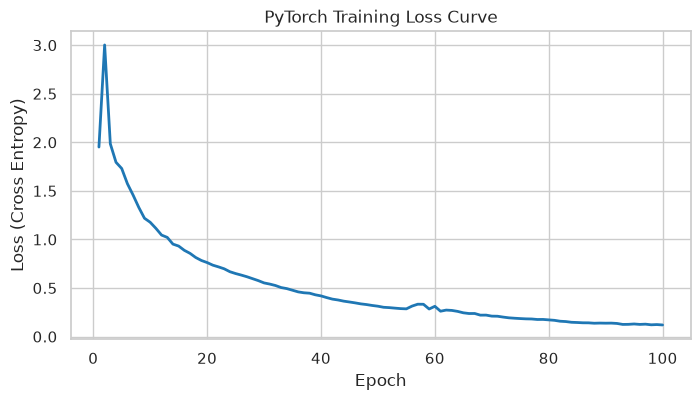

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, color="tab:blue", linewidth=2)
plt.title("PyTorch Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.grid(True)
plt.show()

## Compare Models

In [46]:
comparison_data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "AutoML",
        "Random Forest",
        "Neural Network"
    ],
    "Training Accuracy": [
        lr_train_acc,
        dt_train_acc,
        automl_train_acc,
        rf_train_acc,
        nn_train_acc
    ],
    "Testing Accuracy": [
        lr_test_acc,
        dt_test_acc,
        automl_test_acc,
        rf_test_acc,
        nn_test_acc
    ],
    "Training Time (s)": [
        lr_train_time,
        dt_train_time,
        automl_train_time,
        rf_train_time,
        nn_train_time
    ],
    "Query Time (s)": [
        lr_query_time,
        dt_query_time,
        automl_query_time,
        rf_query_time,
        nn_query_time
    ]
}

# 2. Convert to DataFrame
df_compare = pd.DataFrame(comparison_data)

# 3. Add Best and Worst summary rows
best_row = {
    "Model": "Best",
    "Training Accuracy": df_compare.loc[df_compare["Training Accuracy"].idxmax(), "Model"],
    "Testing Accuracy": df_compare.loc[df_compare["Testing Accuracy"].idxmax(), "Model"],
    "Training Time (s)": df_compare.loc[df_compare["Training Time (s)"].idxmin(), "Model"],
    "Query Time (s)": df_compare.loc[df_compare["Query Time (s)"].idxmin(), "Model"]
}

worst_row = {
    "Model": "Worst",
    "Training Accuracy": df_compare.loc[df_compare["Training Accuracy"].idxmin(), "Model"],
    "Testing Accuracy": df_compare.loc[df_compare["Testing Accuracy"].idxmin(), "Model"],
    "Training Time (s)": df_compare.loc[df_compare["Training Time (s)"].idxmax(), "Model"],
    "Query Time (s)": df_compare.loc[df_compare["Query Time (s)"].idxmax(), "Model"]
}

# Append Best & Worst rows
df_summary = pd.concat([df_compare, pd.DataFrame([best_row, worst_row])], ignore_index=True)
display(df_summary)

,Model,Training Accuracy,Testing Accuracy,Training Time (s),Query Time (s)
0,Logistic Regression,0.634479,0.624113,0.446401,0.013469
1,Decision Tree,0.906398,0.742317,0.038935,0.010945
2,AutoML,0.994076,0.822695,30.151815,0.024738
3,Random Forest,0.954976,0.794326,0.080589,0.013174
4,Neural Network,0.966232,0.744681,0.96412,0.00435
5,Best,AutoML,AutoML,Decision Tree,Neural Network
6,Worst,Logistic Regression,Logistic Regression,AutoML,AutoML


### Confusion Matrix

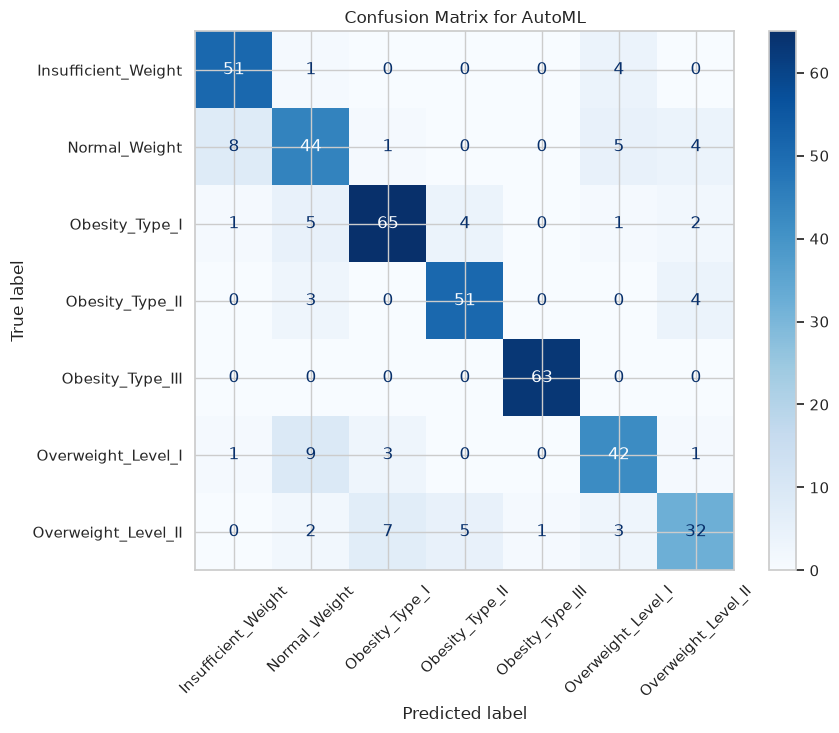

In [47]:
predictions = automl.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=automl.classes_)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=automl.classes_)

disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix for AutoML")
plt.show()


### Classification Report

In [48]:
print(classification_report(y_test, predictions, target_names=automl.classes_))

                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.91      0.87        56
      Normal_Weight       0.69      0.71      0.70        62
     Obesity_Type_I       0.86      0.83      0.84        78
    Obesity_Type_II       0.85      0.88      0.86        58
   Obesity_Type_III       0.98      1.00      0.99        63
 Overweight_Level_I       0.76      0.75      0.76        56
Overweight_Level_II       0.74      0.64      0.69        50

           accuracy                           0.82       423
          macro avg       0.82      0.82      0.82       423
       weighted avg       0.82      0.82      0.82       423



## Save Model

In [49]:
# Save model and metadata
artifact = {
    "model": automl,
    "target_names": df["Obesity_Class"].unique().tolist(),
    "feature_names": automl.feature_names_in_,
}

with open("model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("\nModel saved to model.pkl")



Model saved to model.pkl
